<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Python_chapter9_BayesianOptimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ベイズ的最適化による実験計画法 (のノリ)

以下では、ベイズ的最適化を用いた実験計画法を見てみよう。

数学的な詳細やコードの詳細よりも「なんとなくこのあたりを探索しようかな」といった人間の経験に依る部分を客観的な方法で置き換える方法論の強力さを感じてもらうのが目的なので、難しいところはスキップしてOK。ガウス過程の基本や詳細は講義ノートに譲る.

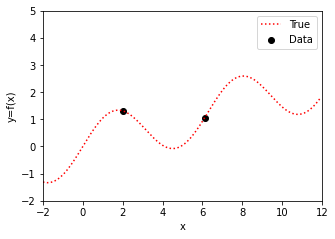

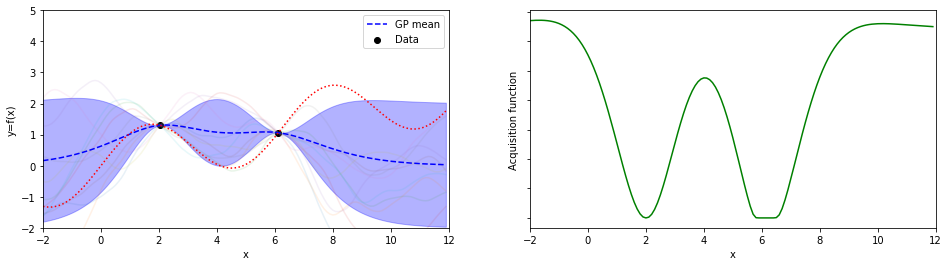

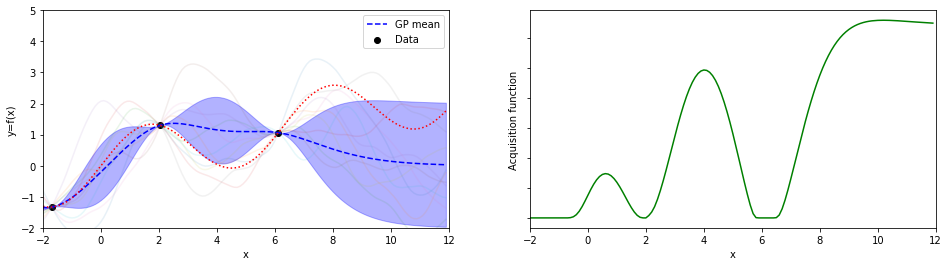

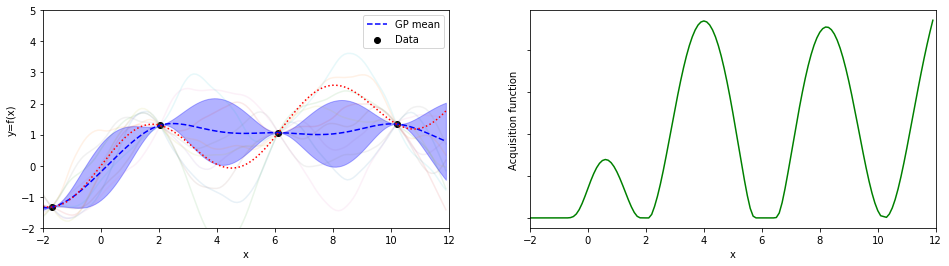

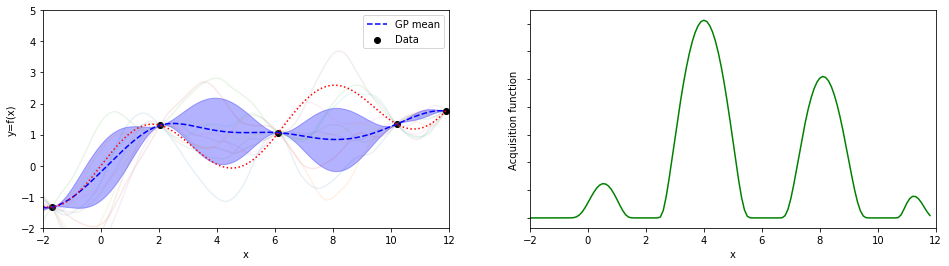

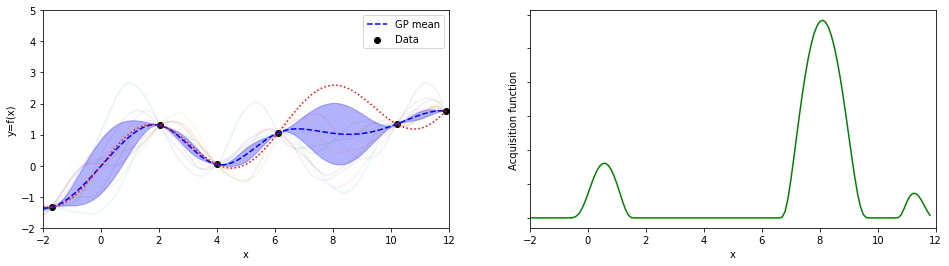

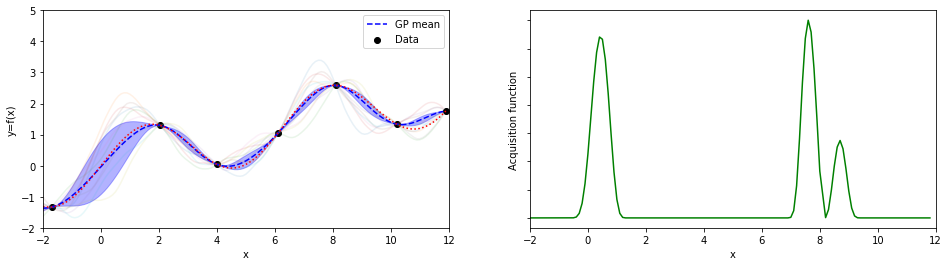

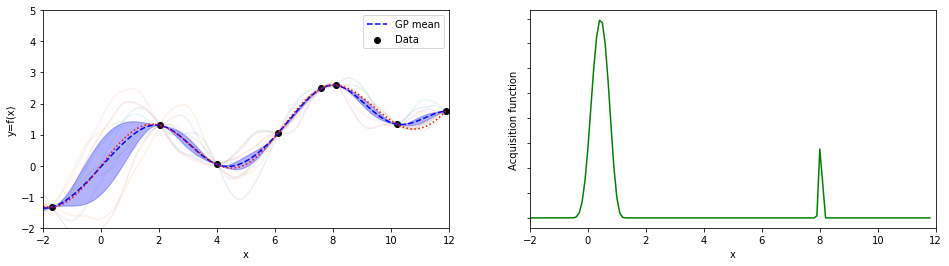

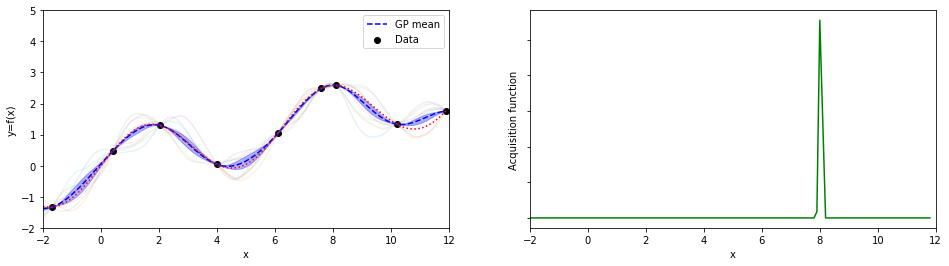

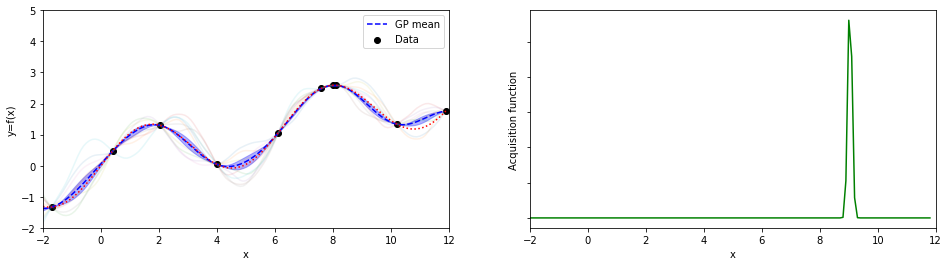

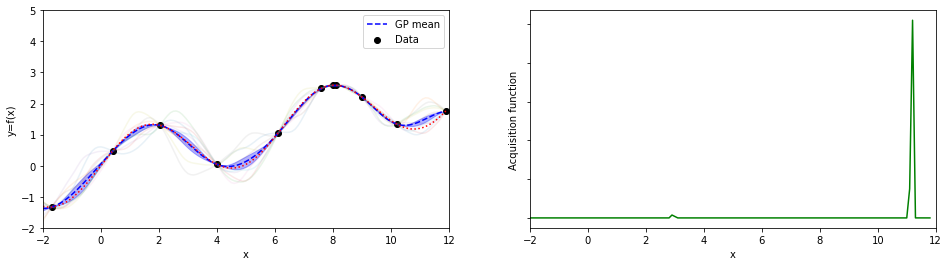

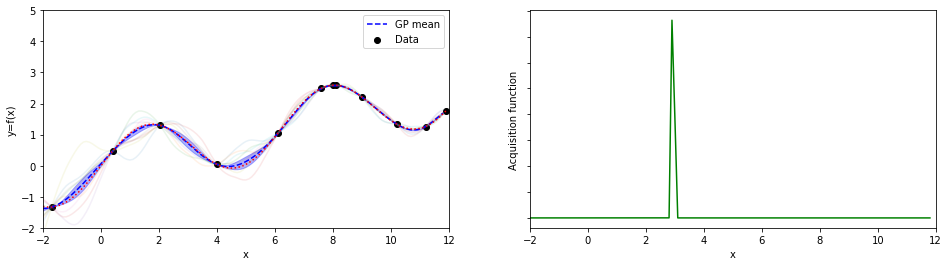

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from scipy import special

## データの生成用関数
def trueF(xt,xp):
    np.random.seed(0)
    sigma= 0.01
    yt = [ np.sin(xt[i]) + 0.2 * xt[i] + sigma* (0.5-np.random.rand()) for i in range(len(xt))]
    ytrue = [np.sin(xp[i]) + 0.2 * xp[i] for i in range(len(xp))]
    return yt,ytrue

## ガウス過程のカーネル(共分散行列)の設計
def Mat52(Thetas,r):
    tau,sigma = Thetas
    theta = np.sqrt(5.0)/sigma
    return tau * (1.0 + theta*r + (theta**2) * (r**2) /3.0) * np.exp(-theta*r)
def KernelMat(Thetas,xt,xp):
    lt = len(xt); lp=len(xp)
    Ktt = np.zeros((lt,lt))
    Kpt = np.zeros((lp,lt))
    Kpp = np.zeros((lp,lp))
    for j in range(lt):
        for i in range(j,lt):
            r = abs(xt[i]-xt[j])
            tmp  = Mat52(Thetas,r) 
            Ktt[i,j] = tmp; Ktt[j,i] = tmp 
        for i in range(lp):
            r= abs(xp[i]-xt[j])
            Kpt[i,j] = Mat52(Thetas,r)
    for j in range(lp):
        for i in range(j,lp):
            r= abs(xp[i]-xp[j])
            tmp  = Mat52(Thetas,r)
            Kpp[i,j] = tmp; Kpp[j,i] = tmp
    return Ktt,Kpt,Kpp

## 事後共分散行列の計算
def calcSj(cLinv,Kpt,Kpp,yt,mu_yt,mu_yp):
    tKtp= np.dot(cLinv,Kpt.T)
    return mu_yp + np.dot(Kpt,np.dot(cLinv.T,np.dot(cLinv,yt-mu_yt))), Kpp - np.dot(tKtp.T,tKtp)

## Cholesky分解
def Mchole(tmpA,ln) :
    cLL = np.linalg.cholesky(tmpA)
    logLii=0.0
    for i in range(ln):
        logLii += np.log(cLL[i,i])
    return np.linalg.inv(cLL), 2.0*logLii

## 次点の計算点を決めるための関数
def xybest(xt,yt):
    xbest,ybest=xt[1],yt[1]
    ind = 1000
    for i in range(len(xt)):
        if yt[i] > ybest :
            xbest,ybest=xt[i],yt[i]
            ind = i
    return xbest,ybest,ind
    
def calcEI(xp,mujoint,sigmaj,xbest,ybest):
    np.random.seed(0)
    EIs = [ (mujoint[i]-ybest) * Phi((mujoint[i]-ybest)/sigmaj[i]) +
            sigmaj[i]* np.exp(-0.5* ((mujoint[i]-ybest)/sigmaj[i])**2) for i in range(len(xp))]
    xnew,ynew,ind=xybest(xp,EIs)
    ynew= np.sin(xnew) + 0.2*xnew + 0.01 * (0.5-np.random.rand())
    return xnew,ynew,EIs,ind

def Phi(z):
    return 0.5 * special.erfc(-(z/(2**0.5)) )

## お絵かき
def plotGP0(xt,yt,xp,ytrue):
    fig = plt.figure(figsize=(5,3.5))
    axT = fig.add_subplot(1,1,1)
    axT.set_xlabel("x"); axT.set_ylabel("y=f(x)")
    axT.set_xlim(-2.0,12); axT.set_ylim(-2.0,5.0)
    axT.scatter(xt,yt,marker="o",color="black",label="Data")
    axT.plot(xp,ytrue,color="red",label="True",linestyle="dotted")
    axT.legend(loc="upper right")
    plt.show()
    #plt.savefig("BayesOpt_initial.pdf",bbox_inches="tight", pad_inches=0.1)
    plt.close()

def plotGP(xt,yt,xp,oxp,ytrue,mujoint,sigmaj,ysamples,EIs):
    fig = plt.figure(figsize=(16,4))
    axT = fig.add_subplot(121)
    axB = fig.add_subplot(122)
    axT.set_xlabel("x"); axT.set_ylabel("y=f(x)")
    axB.set_xlabel("x"); axB.set_ylabel("Acquisition function")
    axT.set_xlim(-2.0,12); axT.set_ylim(-2.0,5.0)
    axB.set_xlim(-2.0,12)#; axB[:set_ylim](-2.0,5.0)
    axT.scatter(xt,yt,marker="o",color="black",label="Data")
    for i in range(len(ysamples)):
        axT.plot(xp,ysamples[i],alpha=0.1)
    axT.plot(xp,mujoint,label="GP mean",linestyle="dashed",color="blue")
    axB.plot(xp,EIs,color="green")
    axB.set_yticklabels([]) 
    axT.fill_between(xp,mujoint-sigmaj,mujoint+sigmaj,color="blue", alpha=0.3)
    axT.legend(loc="upper right")
    axT.plot(oxp,ytrue,color="red",label="True",linestyle="dotted")
    #plt.savefig("BayesOpt_num"+str(len(xt))+".pdf",bbox_inches="tight", pad_inches=0.1)
    plt.show()
    plt.close()

    
Thetas=[2.0,2.0]
oxt = [ 0.0 + 1.02*i for i in range(11)]
xp = []
for tmp in np.arange(-2.0,12.0,0.1):
    if (tmp in oxt)==False:
        xp += [ tmp]
oxt = np.array(oxt);xp = np.array(xp)
oxp = copy.copy(xp)

lt=len(oxt);lp=len(xp)
oyt,ytrue = trueF(oxt,xp)

SVs=[]
xt =[oxt[2],oxt[6]]
yt =[oyt[2],oyt[6]]

plotGP0(xt,yt,xp,ytrue)

for KK in range(11):
    lt=len(xt); lp=len(xp)
    Ktt,Kpt,Kpp = KernelMat(Thetas,xt,xp) ### eval KernelMatrix
    mu_yt= np.array([ 0.0 for i in range(lt)])
    mu_yp= np.array([ 0.0 for i in range(lp)])
    cLinv,logdetK = Mchole(Ktt,lt) 
    mujoint,Sjoint = calcSj(cLinv,Kpt,Kpp,yt,mu_yt,mu_yp)
    sigmaj=[ Sjoint[j][j] for j in range(lp)]
    ysamples = [np.random.multivariate_normal(mujoint,Sjoint) for i in range(10)]
    SVs += [ [ mujoint, sigmaj] ]
    xbest,ybest,ind= xybest(xt,yt)
    xnew,ynew,EIs,ind = calcEI(xp,mujoint,sigmaj,xbest,ybest)
    plotGP(xt,yt,xp,oxp,ytrue,mujoint,sigmaj,ysamples,EIs)
    xt += [ xnew ]; yt += [ ynew ]
    xp = list(xp)
    xp.pop(ind)

探索点が増えるにつれて、効率的に最適解が探索出来ている(っぽい)。

**言及しなかった重要な事項**

* カーネル関数の選択と依存性
* ハイパーパラメータの最適化 or サンプリング
* 獲得関数の定義・選択と依存性
* 数値計算(とくにガウス過程の部分)のTips